# Pricing European Options Using Binomial Trees

A **European option** is the right, but not the obligation, to buy or sell an underlying asset at a specified **strike price** on a **specified date**. Let $S_T$ be the price of the underlying asset at time $T$, where $T$ is the time interval between today and the specified date. Let $K$ be the strike price.

A **European put option** is the right, but not the obligation, to sell an underlying asset at a specified **strike price** on a **specified date**. In that case, the **payoff** of the option is $\max(K - S_T, 0)$.

A **European call option** is the right, but not the obligation, to buy an underlying asset at a specified **strike price** on a **specified date**. In that case, the **payoff** of the option is $\max(S_T - K, 0)$.

We assume here that the underlying asset is a share of a stock. 

### Goal

Our goal is to price a European option given the stock, the strike price, and the time interval $T$ (in years) between the day the contract is made and the maturity date. 

The method we use here is based on **binomial trees**.

## Introduction

Let $S_0$ be the stock price now and $S_1$ be the stock price after one time period. In the binomial model, we assume that after one time period, the stock price can either go up to attain a value of $S_1 = u \cdot S_0$, or it can go down to $S_1 = d \cdot S_0$, where $0 < d < 1 < u$. Let $S_2$ denote the stock price at the end of two time periods.

- If $S_1 = u \cdot S_0$, then it can either increase to $S_2 = u \cdot S_1 = u^2 \cdot S_0$ or decrease to $S_2 = d \cdot S_1 = d \cdot u \cdot S_0$.
- If $S_1 = d \cdot S_0$, then it can either increase to $S_2 = u \cdot S_1 = u \cdot d \cdot S_0$ or decrease to $S_2 = d \cdot S_1 = d^2 \cdot S_0$.

In general, the stock price after $t$ time periods is given by

$$ S_t = uS_{t - 1} \text{ or } S_t = dS_{t - 1} .$$

Here, $t = 1, 2,..., N$, where $N$ is the total number of time periods in the binomial tree.

We use the following values of $u$ and $d$, as proposed by Cox, Ross, and Rubinstein (1979):

$$ u = e^{\sigma \sqrt{\Delta t}} \text{ and } d = \frac{1}{u} = e^{-\sigma \sqrt{\Delta t}} $$

where $\sigma$ denotes the volatility of the stock and $\Delta t$ denotes the length of the time period in years. 

If $T$ denotes the total time in years till the maturity of the option, then $\Delta t = \frac{T}{N}$.

We first calculate the volatility $\sigma$ of the stock as the annualized standard deviation of the daily log returns of the stock:

In [1]:
import numpy as np
import yfinance as yf

In [2]:
'''
Calculating the daily log returns of a stock.
ticker: a Ticker object
Returns an ndarray containing the daily log returns of the stock.
'''

def calc_daily_log_return(ticker):
    
    # The history() method of a Ticker object returns a Pandas DataFrame which is converted to an ndarray by the method to_numpy()
    close_history = ticker.history(period="2y")["Close"].to_numpy()
    
    daily_log_return = np.log(close_history[1:]/close_history[:-1])

    return daily_log_return

In [3]:
'''
Calculating the volatility of the stock price.
Takes as input a Ticker object.
'''

def volatility(ticker):
    
    daily_ret = calc_daily_log_return(ticker)
    sigma = np.std(daily_ret, ddof=1) * np.sqrt(252) # np.std(daily_ret) gives the daily volatility, multiply by sqrt(252) to obtain the annual volatility

    return sigma

## Stock Lattice

Let $S_{i, t}$ be the stock price in state $i$ and after $t$ time periods, with $S_{0, 0} = S_0$, the initial stock price. Here, the state $i$ denotes the number of **downward** movements, and so the number of upward movements is given by $t - i$. Hence,

$$ S_{i, t + 1} = u \cdot S_{i, t} $$

and

$$ S_{i + 1, t + 1} = d \cdot S_{i, t} .$$

The binomial tree for stock prices can be implemented as an $(N + 1) \times (N + 1)$ `ndarray`, where $N$ is the total number of time periods.

In [4]:
'''
Calculating the binomial tree for simulating stock prices.
S0: current stock price
u: up factor
N: number of time periods
'''

def stock_bt(S0, u, N):
    d = 1 / u
    S = np.zeros((N + 1, N + 1))
    S[0, 0] = S0

    for t in range(1, N + 1):
        for i in range(t):
            S[i, t] = u * S[i, t - 1]
            S[i + 1, t] = d * S[i, t - 1]

    return S   

Consider the following example:

In [5]:
S0 = 36.  # current stock price
T = 1.    # time till maturity (in years)
sigma = 0.2   # volatility

N = 4   # number of time periods
dt = T / N   # duration of each time period (in years)

u = np.exp(sigma * np.sqrt(dt))  # up factor

S = stock_bt(S0, u, N) 

np.set_printoptions(formatter={'float':
                              lambda x: '%6.2f' % x})

print(S)

[[ 36.00  39.79  43.97  48.59  53.71]
 [  0.00  32.57  36.00  39.79  43.97]
 [  0.00   0.00  29.47  32.57  36.00]
 [  0.00   0.00   0.00  26.67  29.47]
 [  0.00   0.00   0.00   0.00  24.13]]


To obtain the execution time for $N = 500$:

In [6]:
N = 500
dt = T / N
u = np.exp(sigma * np.sqrt(dt))

%time stock_bt(S0, u, N)

CPU times: user 105 ms, sys: 2.99 ms, total: 108 ms
Wall time: 107 ms


array([[ 36.00,  36.32,  36.65, ..., 3095.69, 3123.50, 3151.57],
       [  0.00,  35.68,  36.00, ..., 3040.81, 3068.13, 3095.69],
       [  0.00,   0.00,  35.36, ..., 2986.89, 3013.73, 3040.81],
       ...,
       [  0.00,   0.00,   0.00, ...,   0.42,   0.42,   0.43],
       [  0.00,   0.00,   0.00, ...,   0.00,   0.41,   0.42],
       [  0.00,   0.00,   0.00, ...,   0.00,   0.00,   0.41]],
      shape=(501, 501))

### *Improving the Execution Time*


In order to decrease the execution time, we can vectorize this function. 

Since $i$ denotes the number of downward movements, we have that $S_{i, t} = u^{t - i} d^{i} S_0$. But in our binomial tree, $d = \frac{1}{u}$ and so $S_{i, t} = u^{t - 2i} S_0$. We can use this fact to vectorize the function `stock_bt` as follows:

In [7]:
N = 4
up = np.arange(N + 1)
up

array([0, 1, 2, 3, 4])

In [8]:
up = np.resize(up, (N + 1, N + 1))
up

array([[0, 1, 2, 3, 4],
       [0, 1, 2, 3, 4],
       [0, 1, 2, 3, 4],
       [0, 1, 2, 3, 4],
       [0, 1, 2, 3, 4]])

In [9]:
down = 2 * up.T
down

array([[0, 0, 0, 0, 0],
       [2, 2, 2, 2, 2],
       [4, 4, 4, 4, 4],
       [6, 6, 6, 6, 6],
       [8, 8, 8, 8, 8]])

In [10]:
up - down

array([[ 0,  1,  2,  3,  4],
       [-2, -1,  0,  1,  2],
       [-4, -3, -2, -1,  0],
       [-6, -5, -4, -3, -2],
       [-8, -7, -6, -5, -4]])

Notice that for each row $r$ and column $c$, `(up - down)[r][c]`  is $r - 2c$. This is used in the following function:

In [11]:
'''
Calculating the binomial tree for simulating stock prices.
S0: current stock price
u: up factor
N: number of time periods
Vectorized version, uses NumPy
'''

def stock_bt_v(S0, u, N):
    d = 1 / u

    up = np.arange(N + 1)
    up = np.resize(up, (N + 1, N + 1))

    down = up.T * 2

    S = S0 * np.power(u, up - down)    

    return S   

For example:

In [12]:
dt = T / N
u = np.exp(sigma * np.sqrt(dt))

S = stock_bt_v(S0, u, N)

print(S)

[[ 36.00  39.79  43.97  48.59  53.71]
 [ 29.47  32.57  36.00  39.79  43.97]
 [ 24.13  26.67  29.47  32.57  36.00]
 [ 19.76  21.84  24.13  26.67  29.47]
 [ 16.18  17.88  19.76  21.84  24.13]]


Execution time for the vectorized function where $N = 500$:

In [13]:
N = 500
dt = T / N
u = np.exp(sigma * np.sqrt(dt))

%time stock_bt_v(S0, u, N)

CPU times: user 21.2 ms, sys: 13.7 ms, total: 34.8 ms
Wall time: 31.8 ms


array([[ 36.00,  36.32,  36.65, ..., 3095.69, 3123.50, 3151.57],
       [ 35.36,  35.68,  36.00, ..., 3040.81, 3068.13, 3095.69],
       [ 34.73,  35.05,  35.36, ..., 2986.89, 3013.73, 3040.81],
       ...,
       [  0.00,   0.00,   0.00, ...,   0.42,   0.42,   0.43],
       [  0.00,   0.00,   0.00, ...,   0.41,   0.41,   0.42],
       [  0.00,   0.00,   0.00, ...,   0.40,   0.41,   0.41]],
      shape=(501, 501))

Thus, vectorizing the function has resulted in a significant speedup. 

For further improvement, we use **Numba**:

In [14]:
import numba

stock_bt_nb = numba.jit(stock_bt)  # numba accelerates code that contains explicit Python loops, scalar operations

In [15]:
stock_bt_nb(S0, u, N)

array([[ 36.00,  36.32,  36.65, ..., 3095.69, 3123.50, 3151.57],
       [  0.00,  35.68,  36.00, ..., 3040.81, 3068.13, 3095.69],
       [  0.00,   0.00,  35.36, ..., 2986.89, 3013.73, 3040.81],
       ...,
       [  0.00,   0.00,   0.00, ...,   0.42,   0.42,   0.43],
       [  0.00,   0.00,   0.00, ...,   0.00,   0.41,   0.42],
       [  0.00,   0.00,   0.00, ...,   0.00,   0.00,   0.41]],
      shape=(501, 501))

In [16]:
%time stock_bt_nb(S0, u, N)

CPU times: user 286 μs, sys: 1.01 ms, total: 1.29 ms
Wall time: 1.31 ms


array([[ 36.00,  36.32,  36.65, ..., 3095.69, 3123.50, 3151.57],
       [  0.00,  35.68,  36.00, ..., 3040.81, 3068.13, 3095.69],
       [  0.00,   0.00,  35.36, ..., 2986.89, 3013.73, 3040.81],
       ...,
       [  0.00,   0.00,   0.00, ...,   0.42,   0.42,   0.43],
       [  0.00,   0.00,   0.00, ...,   0.00,   0.41,   0.42],
       [  0.00,   0.00,   0.00, ...,   0.00,   0.00,   0.41]],
      shape=(501, 501))

### *Visualization*

We can visualize the stock price lattice as follows:

In [17]:
from pylab import plt

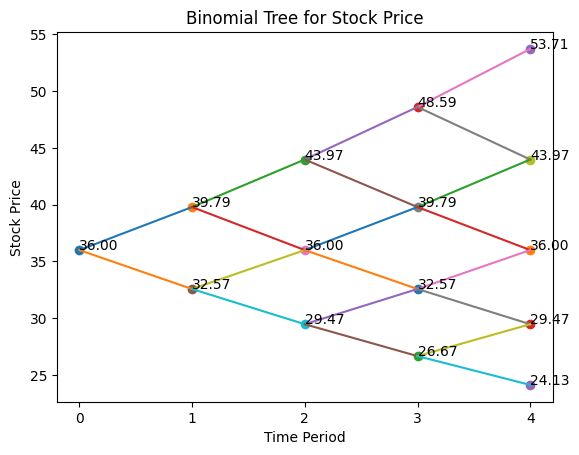

In [18]:
'''
Visualizing the stock price lattice.
S: ndarray containing the stock price lattice
'''

def plot_stock(S):
    rows, cols = S.shape

    for r in range(rows):
        for t in range(r, cols):            
                plt.scatter(t, S[r, t])  # plots a single point
                plt.text(t, S[r, t], f"{S[r,t]:.2f}", fontsize=10)  # adds text at the point                

                if t + 1 < cols:  # ensures we are not at the last column                    
                    plt.plot([t, t + 1], [S[r, t], S[r, t + 1]])  # plots the up line
                    
                    if r + 1 < rows: # checks if the row below exists
                        plt.plot([t, t + 1], [S[r, t], S[r + 1, t + 1]])  # plots the down line

    plt.xlabel("Time Period")
    plt.xticks(range(cols))
    plt.ylabel("Stock Price")
    plt.title("Binomial Tree for Stock Price")
    plt.show()

plot_stock(S)

## Option Lattice

Consider a one-period binomial model with $S_0$ as the current stock price. Let $u$ be the up factor and $d$ be the down factor. 

Suppose we want to price a European option which expires after one period. Then, the payoff after one period is given by $\max(0, S_1 - K)$ for a call option and $\max(0, K - S_1)$ for a put option, where $S_1$ is the stock price at maturity and $K$ is the strike price. Then, $S_1$ is either $uS_0$ or $dS_0$. Let $f_u$ be the payoff of the option after an upward movement and $f_d$ after a downward movement. Then, the option price $f$ at time $0$ is given by:

$$ f = e^{-r\Delta t}[pf_u + (1 - p)f_d] $$

Here, $\Delta t$ is the length of one time period (in years) and $r$ is the riskless short rate and $p$ is the risk-neutral probability of an upward movement, given by:

$$ p = \frac{e^{r\Delta t} - d}{u - d} $$

This formula can be applied to multi-period binomial models at each node.

The following function calculates $p$:

In [19]:
'''
Calculating the risk-neutral probability p
r: risk-free rate
dt: length of each time step (in years)
u: up factor
'''

def calc_p(r, dt, u):
    d = 1 / u
    return (np.exp(r * dt) - d) / (u - d)

The riskless short rate $r$ is approximated by Treasury-bill yields. We obtain them based on the time horizon. For instance, if the maturity is 3 months from now, we use the yield of the three-month T-bill. If we obtain the yield as $r_y$ then, assuming continuous compounding, the riskless rate is given by

$$ r = \ln(1 + r_y) $$

In [20]:
import pandas_datareader.data as web
import datetime as dtm

In [21]:
'''
This function takes t, the time interval between today and maturity, in years.
'''

def calc_r(t):
    start = dtm.datetime(2026,1,1)  # start date, irrelevant here but required as an argument in the DataReader function
    end = dtm.datetime.today()
    r_y = 0

    # 3 month horizon, use 3-month T-bill
    if t <= 0.25:
        r_y = web.DataReader("DTB3", "fred", start, end).iloc[-1,0] / 100 # rates are returned in percentage and so division by 100
    
    # 3 to 6 month horizon, use 6-month T-bill
    elif t <= 0.5:
        r_y = web.DataReader("DTB6", "fred", start, end).iloc[-1,0] / 100
    
    # for longer time horizons, use 1-year T-bill
    else:
        r_y = web.DataReader("DTB1YR", "fred", start, end).iloc[-1,0] / 100

    r = np.log(1 + r_y)  # this is the annual riskless rate

    return r

To calculate the binomial tree for the option price, we first calculate the option payoff at maturity. Let $S_{i, t}$ and $O_{i, t}$ denote the stock price and the option price in the $i$-th state after $t$ periods, respectively. Then, for $t = T$, $O_{i, T} = \max(0, S_{i, T} - K)$ if it is a call option or $O_{i, T} = \max(0, K - S_{i, T})$ if it is a put option. We then work backwards through the lattice. 

At each time step $t = 0, 1, ..., N - 1$, the expected option price is given by:

$$ f_{i, t} = e^{-r\Delta t} [pf_{i, t + 1} + (1 - p)f_{i + 1, t + 1}] $$

where $f_{i, t}$ denotes the option price in state $i$ and after $t$ periods.

The following function uses this method to calculate the price of a European option:

In [22]:
'''
Calculating the binomial tree for simulating the option price. 
S: ndarray representing the binomial tree for stock price, calculated using function stock_bt_nb()
K: strike price
p: risk-neutral probability of the stock going up
df: discount factor, exp(-r * dt)
opt: takes the strings "call" or "put" as an argument, "call" by default
'''

def option_bt(S, K, p, df, opt="call"):
    O = np.zeros_like(S)
    rows, cols = S.shape
    T = cols - 1  # last time period
    
    # valuing the option at time T (maturity)
    if opt == "put":
        for row in range(rows):
            O[row, T] = max(K - S[row, T], 0)

    if opt == "call":
        for row in range(rows):
            O[row, T] = max(S[row, T] - K, 0)
    
    # working backwards in the lattice
    t = T - 1
    while t >= 0:
        for row in range(t + 1):
            O[row, t] = df * (p * O[row, t + 1] + (1 - p) * O[row + 1, t + 1])

        t -= 1
    
    return O

Consider the following example:

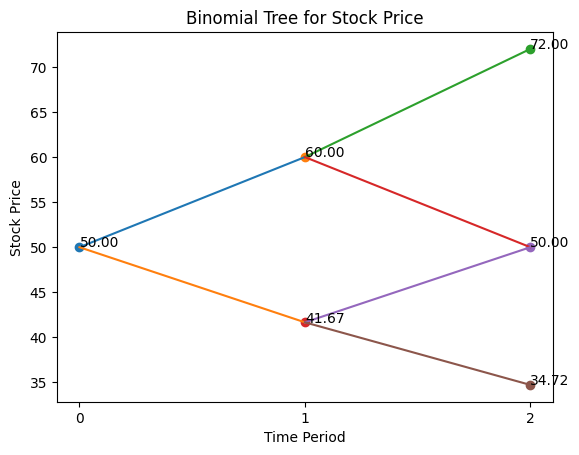

In [23]:
S0 = 50.    # current stock price
T = 2       # total time (in years) till maturity
N = 2       # number of time periods
dt = T / N  # length of each time period
u = 1.2     # up factor

S = stock_bt_nb(S0, u, N)
plot_stock(S)

Then, we can obtain the option lattice as follows:

In [24]:
K = 52.   # strike price
r = 0.05  # riskless rate

p = calc_p(r, dt, u)   # risk-neutral probability
df = np.exp(-r * dt)   # discount factor

O = option_bt(S, K, p, df, "put")
print(O)

[[  3.44   0.77   0.00]
 [  0.00   7.80   2.00]
 [  0.00   0.00  17.28]]


To visualize this, we use the following function:

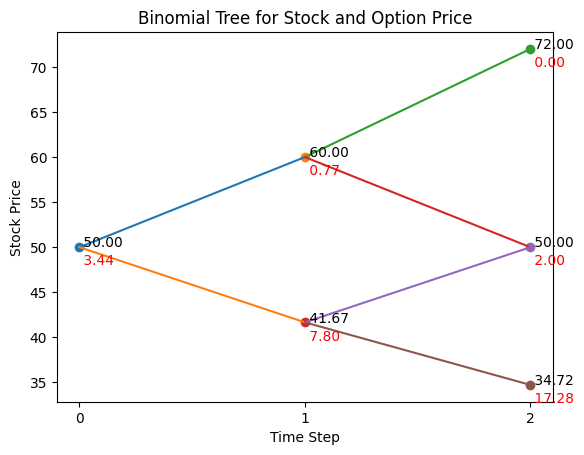

In [25]:
'''
Visualizing the lattice with both stock and option prices.
S: stock price lattice
O: option price lattice
'''

def plot_opt(S, O):
    rows, cols = S.shape

    for i in range(rows):
        for t in range(i, cols):
            plt.scatter(t, S[i, t])
            plt.text(t, S[i, t], f"{S[i,t]: .2f}")
            plt.text(t, S[i, t] - 2, f"{O[i,t]: .2f}", color="red")

            if t + 1 < cols:
                plt.plot((t, t + 1), (S[i, t], S[i, t + 1]))

                if i + 1 < rows:
                    plt.plot((t, t + 1), (S[i, t], S[i + 1, t + 1]))

    plt.xlabel("Time Step")
    plt.ylabel("Stock Price")
    plt.xticks(range(cols))
    plt.title("Binomial Tree for Stock and Option Price")
    plt.show()

plot_opt(S, O)

We can now price a European option as follows:

In [26]:
'''
Pricing a European option.
ticker_symb: string representing a ticker symbol like "AAPL"
K: strike price
T: time (in years) till maturity
N: number of periods
opt: takes one of two strings, "call" or "put", "call" by default
'''

def eu_opt_bt(ticker_symb, T, N, K, opt="call"):
    ticker = yf.Ticker(ticker_symb)

    sigma = volatility(ticker)
    dt = T / N     # length of each period
    r = calc_r(T)  # riskless rate

    S0 = ticker.history(period="5d")["Close"].iloc[-1]
    u = np.exp(sigma * np.sqrt(dt))

    S = stock_bt_nb(S0, u, N)  # stock binomial tree

    p = calc_p(r, dt, u)
    df = np.exp(-r * dt)

    O = option_bt(S, K, p, df, opt)

    return O

As an example, we consider a European call option on one share of the Apple stock with a strike price of $\$280$ and maturity one year from now:

In [27]:
for i in range(1, 21):
    O = eu_opt_bt("AAPL", 1, i * 10, 280, "call")
    print("For " + str(i * 10) + " periods, the option price is: " + f"{O[0, 0]: .2f}")

For 10 periods, the option price is:  24.20
For 20 periods, the option price is:  23.79
For 30 periods, the option price is:  23.56
For 40 periods, the option price is:  23.41
For 50 periods, the option price is:  23.42
For 60 periods, the option price is:  23.52
For 70 periods, the option price is:  23.56
For 80 periods, the option price is:  23.59
For 90 periods, the option price is:  23.59
For 100 periods, the option price is:  23.59
For 110 periods, the option price is:  23.58
For 120 periods, the option price is:  23.57
For 130 periods, the option price is:  23.56
For 140 periods, the option price is:  23.55
For 150 periods, the option price is:  23.53
For 160 periods, the option price is:  23.52
For 170 periods, the option price is:  23.50
For 180 periods, the option price is:  23.48
For 190 periods, the option price is:  23.50
For 200 periods, the option price is:  23.51


We can compare these values with values obtained from the Monte Carlo pricing of the same option under the Black-Scholes-Merton model:

In [28]:
%%capture
%run eu_opt_mcs.ipynb

In [29]:
for i in range(1, 21):
    price = eu_opt_mcs('AAPL', 1, i * 10000, 280, "call")[0]
    print("For " + str(i * 10000) + " simulations, the option price is: " + f"{price: .2f}")

For 10000 simulations, the option price is:  23.28
For 20000 simulations, the option price is:  23.93
For 30000 simulations, the option price is:  23.20
For 40000 simulations, the option price is:  23.42
For 50000 simulations, the option price is:  23.46
For 60000 simulations, the option price is:  23.55
For 70000 simulations, the option price is:  23.61
For 80000 simulations, the option price is:  23.58
For 90000 simulations, the option price is:  23.14
For 100000 simulations, the option price is:  23.40
For 110000 simulations, the option price is:  23.44
For 120000 simulations, the option price is:  23.35
For 130000 simulations, the option price is:  23.68
For 140000 simulations, the option price is:  23.44
For 150000 simulations, the option price is:  23.51
For 160000 simulations, the option price is:  23.56
For 170000 simulations, the option price is:  23.41
For 180000 simulations, the option price is:  23.57
For 190000 simulations, the option price is:  23.60
For 200000 simulation

As can be seen, the price of the option given by the method of binomial trees matches closely the price obtained by Monte Carlo pricing of the option, as expected. 